In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.cm import ScalarMappable
from matplotlib import gridspec
import matplotlib.lines as mlines
from matplotlib.transforms import blended_transform_factory
import os, gc, sys, glob, string, argparse
from tqdm import tqdm
import time
import string
import itertools
import sys
import pickle
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
#from climsim_utils.data_utils import *



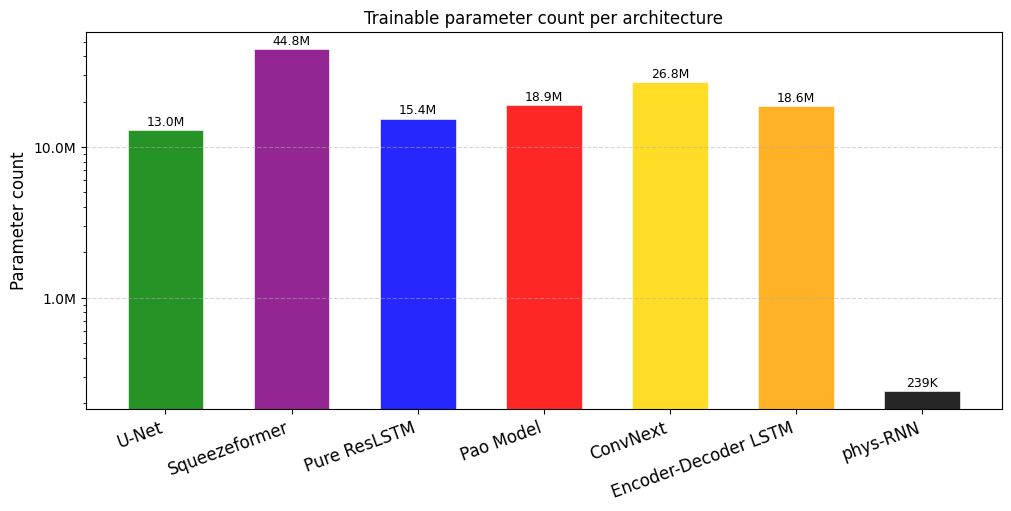

In [2]:
import numpy as np
import matplotlib.pyplot as plt

param_count = {
    "U-Net":                 12975373,
    "Squeezeformer":         44785225,
    "Pure ResLSTM":          15395341,
    "Pao Model":             18876133,
    "ConvNext":              26805429,
    "Encoder-Decoder LSTM":  18582976,
    "phys-RNN":                238832,
}
colors = {
    'U-Net': 'green',
    'Squeezeformer': 'purple',
    'Pure ResLSTM': 'blue',
    'Pao Model': 'red',
    'ConvNext': 'gold',
    'Encoder-Decoder LSTM': 'orange',
    'phys-RNN': 'black',
}

def format_param(v):
    if v >= 1e6:
        return f'{v/1e6:.1f}M'
    elif v >= 1e3:
        return f'{v/1e3:.0f}K'
    return str(v)

names  = list(param_count.keys())
counts = list(param_count.values())
x      = np.arange(len(names))

fig, ax7 = plt.subplots(figsize=(10, 5), constrained_layout=True)

bars = ax7.bar(x, counts, width=0.6,
               color=[colors[n] for n in names],
               alpha=0.85, edgecolor='white', linewidth=0.5)

for bar, v in zip(bars, counts):
    ax7.text(
        bar.get_x() + bar.get_width() / 2,
        v * 1.03,                          # slightly above bar top on log scale
        format_param(v),
        ha='center', va='bottom', fontsize=8.9
    )

ax7.set_yscale('log')
ax7.set_title('Trainable parameter count per architecture')
ax7.set_ylabel('Parameter count',fontsize=12)
ax7.set_xticks(x)
ax7.set_xticklabels(names, rotation=20, ha='right', fontsize=12)
ax7.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: format_param(v)))
ax7.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig("param_counts.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
ax7.get_ylim()[1]

np.float64(58181762.43279659)

In [3]:
# approximate 1-year results on CPU 

SYPD_unet = 6.3
SYPD_physrnn = 17.14

RMSE_unet = {
"T": (1.901, 1.915, 1.985),
"Q": (0.59960, 0.54518, 0.65916),
"CLDLIQ": (20.654, 9.7468, 10.01),
"CLDICE": (6.41842, 7.0965, 7.07261),
"U": (4.24273,  4.029, 4.2554),
"V": ( 2.900, 2.852, 2.9740)
}

RMSE_rnn = {
"T": (2.2485, 2.397, 1.961),
"Q": (0.70853, 0.7555, 0.55976),
"CLDLIQ": (13.0789, 10.474,  9.3795),
"CLDICE": (8.5394, 6.5193, 5.85656),
"U": (4.4133,  4.590, 4.1912), 
"V": ( 2.954, 2.996, 2.8099)
}


In [4]:
param_count = {
"U-Net": 12975373,
"Squeezeformer" : 44785225,
"Pure ResLSTM" : 15395341,
"Pao Model" : 18876133,
"ConvNext" : 26805429,
"Encoder-Decoder LSTM" : 18582976,
"phys-RNN": 238832}

In [5]:
SYPD_CPU =  {
    "U_net":  6.31,
    "pure_resLSTM": 5.67,
    "physRNN": 17.14
}

SYPD_CPU_mmf = 0.95



In [10]:
def calculate_rmse_qn(ds1, ds2, total_weight):
    # Determine the number of months in ds1
    num_months = ds1['CLDLIQ'].shape[0]
    
    # Slice total_weight to match the number of months in ds1
    total_weight_sliced = total_weight[:num_months, :, :]
    
    # Initialize the RMSE array with NaN values
    rmse_per_month = np.full(12, np.nan)
    
    # Compute RMSE for existing months
    squared_diff = (ds1['CLDLIQ'] - ds2['CLDLIQ'] + ds1['CLDICE'] - ds2['CLDICE']) ** 2
    weighted_squared_diff = squared_diff * total_weight_sliced
    weighted_sum = weighted_squared_diff.sum(axis=(1, 2))
    total_weight_sum = total_weight_sliced.sum(axis=(1, 2))
    weighted_mean_squared_diff = weighted_sum / total_weight_sum
    rmse_existing_months = np.sqrt(weighted_mean_squared_diff)
    
    # Fill in the RMSE array with the computed values
    rmse_per_month[:num_months] = rmse_existing_months.values
    
    return rmse_per_month

# Function to calculate RMSE per month for other variables (T, Q, U)
def calculate_rmse(ds1, ds2, total_weight,var='T'):
    # Determine the number of months in ds1
    num_months = ds1[var].shape[0]
    
    # Slice total_weight to match the number of months in ds1
    total_weight_sliced = total_weight[:num_months, :, :]
    
    # Initialize the RMSE array with NaN values
    rmse_per_month = np.full(12, np.nan)
    
    # Compute RMSE for existing months
    squared_diff = (ds1[var] - ds2[var]) ** 2
    weighted_squared_diff = squared_diff * total_weight_sliced
    weighted_sum = weighted_squared_diff.sum(axis=(1, 2))
    total_weight_sum = total_weight_sliced.sum(axis=(1, 2))
    weighted_mean_squared_diff = weighted_sum / total_weight_sum
    rmse_existing_months = np.sqrt(weighted_mean_squared_diff)
    
    # Fill in the RMSE array with the computed values
    rmse_per_month[:num_months] = rmse_existing_months.values
    
    return rmse_per_month
    
data_path = '/data/ClimSim/hu_etal2024_data/'
data_path_docker = "/data/climsim-online/scratch/"

pattern = '*.eam.h0.0003*.nc'

ds_sp = xr.open_dataset(data_path + 'h0/1year/mmf_ref/mmf_ref.eam.h0.0003.nc')
print("Shape true:", ds_sp.T.shape)
ds_sp['lev'].attrs['long_name'] = 'hybrid pressure'

ps_sp = ds_sp.PS
p_interface = ds_sp.hyai*ds_sp.P0 + ds_sp.hybi*ds_sp.PS
p_interface = p_interface.values
p_interface = np.transpose(p_interface, (1,0,2))
dp = p_interface[:,1:61,:] - p_interface[:,0:60,:]
area = ds_sp.area
area_weight = area.values[np.newaxis,np.newaxis,:]
total_weight = dp*area_weight
total_weight.shape


case_groups =  [
    # U-NET
    [
    'unet_v5/huber_rop',
    'unet_v5/huber_step',
    'unet_v5/mae_step'
    ],
 # U-NET lin et al
    [
    'ckpt_ftorch_cpu2_unet_v6_1024_epoch_12_metric_0.0507',
    ],
    # Pure ResLSTM
    ['ckpt_ftorch_cpu2_pure_resLSTM_v6_1024_epoch_12_metric_0.0513',
     'ckpt_ftorch_cpu2_pure_resLSTM_v6_43_epoch_12_metric_0.0513',
     'ckpt_ftorch_cpu2_pure_resLSTM_v6_7_epoch_12_metric_0.0513'
    ],
    # ConvNext
    ['ckpt_ftorch_cpu2_convnext_v6_1024_epoch_12_metric_0.0496',
     'ckpt_ftorch_cpu2_convnext_v6_43_epoch_12_metric_0.0496',
     'ckpt_gpu_convnext_v6_1024_epoch_12_metric_0.0496'
    ],
    # PhysRNN+physrad
    [ 
     #'32534',
     '83631',
     '53373_ep46',
     '41075']
    # add encoder-decoder LSTM: Lin et al said was best in SYPD vs RMSE
    # but this was bad with expanded inputs? use convnext instead?
]

model_labels = ["U_net", "U_net_lin", "Pure ResLSTM", "ConvNeXt", "physRNN"]

varnames = ["T", "Q", "CLDLIQ", "CLDICE","CLDTOT","U","V"]

rmse_dict = {}


# Load the three reference MMF runs (same initial conditions, diverge due to natural variability / round off errors)
model_family = "REF"
ref_runs = {
    "mmf_a": xr.open_dataset(data_path + 'h0/1year/mmf_a/mmf_a.eam.h0.0003.nc'),
    "mmf_b": xr.open_dataset(data_path + 'h0/1year/mmf_b/mmf_b.eam.h0.0003.nc'),
    "mmf_c": xr.open_dataset(data_path + 'h0/1year/mmf_c/mmf_c.eam.h0.0003.nc'),
}

for casename, ds_ref in ref_runs.items():
    for var in varnames:
        if var in ["CLDTOT", "CLDLIQ", "CLDICE"]:
            if var == "CLDTOT":
                rmse_per_month = calculate_rmse_qn(ds_ref, ds_sp, total_weight) * 1e6
            else:
                rmse_per_month = calculate_rmse(ds_ref, ds_sp, total_weight, var) * 1e6
        elif var == "Q":
            rmse_per_month = calculate_rmse(ds_ref, ds_sp, total_weight, var) * 1e3
        else:
            rmse_per_month = calculate_rmse(ds_ref, ds_sp, total_weight, var)

        rmse_dict[("REF", casename, var)] = rmse_per_month

# and now the NN runs
for group_idx, group in enumerate(case_groups):
    model_family = model_labels[group_idx]
    print(group_idx, model_family)

    for case_idx, casename in enumerate(group):
        if "ckpt" in casename:
            ds_nn = xr.open_mfdataset(data_path_docker + f'{casename}/run/*.eam.h0.0003-*.nc',data_vars='minimal', coords='minimal', compat='override')
        elif "unet" in casename:
            ds_nn = xr.open_mfdataset(data_path + f'h0/1year/{casename}/*.eam.h0.0003-*.nc', data_vars='minimal', coords='minimal', compat='override')       
        else:
            ds_nn = xr.open_mfdataset(data_path_docker + f'example_job_submit_nnwrapper_v4_rnn_{casename}/run/*.eam.h0.0003-*.nc', data_vars='minimal', coords='minimal', compat='override')

        for var in varnames:
            if var in ["CLDTOT", "CLDLIQ", "CLDICE"]:
                if var == "CLDTOT":
                    rmse_per_month_nn = calculate_rmse_qn(ds_nn, ds_sp, total_weight) * 1e6
                else:
                    rmse_per_month_nn = calculate_rmse(ds_nn, ds_sp, total_weight, var) * 1e6
            elif var == "Q":
                rmse_per_month_nn = calculate_rmse(ds_nn, ds_sp, total_weight, var) * 1e3
            else:
                rmse_per_month_nn = calculate_rmse(ds_nn, ds_sp, total_weight, var)

            mean_err = rmse_per_month_nn
            rmse_dict[(model_family, casename, var)] = mean_err  


# mean_err = np.nanmean(rmse_dict[(model_family, casename, var)])
            

Shape true: (12, 60, 384)
0 U_net
1 U_net_lin
2 Pure ResLSTM
3 ConvNeXt
4 physRNN


In [38]:
varname="T"
{k: np.nanmean(v) for k, v in rmse_dict.items() if k[0] == 'REF' and k[2] == varname}

{('REF', 'mmf_a', 'T'): np.float64(1.3925041975879875),
 ('REF', 'mmf_b', 'T'): np.float64(1.3927301646491632),
 ('REF', 'mmf_c', 'T'): np.float64(1.3871212637886703)}

In [63]:
{k: np.nanmean(v) for k, v in rmse_dict.items() if k[0] == 'Pure ResLSTM' and k[2] == varname}

{('Pure ResLSTM',
  'ckpt_ftorch_cpu2_pure_resLSTM_v6_1024_epoch_12_metric_0.0513',
  'T'): np.float64(7.1266025881474135),
 ('Pure ResLSTM',
  'ckpt_ftorch_cpu2_pure_resLSTM_v6_43_epoch_12_metric_0.0513',
  'T'): np.float64(12.229012992878786),
 ('Pure ResLSTM',
  'ckpt_ftorch_cpu2_pure_resLSTM_v6_7_epoch_12_metric_0.0513',
  'T'): np.float64(707.7472271085993)}

In [68]:
{k: np.nanmean(v) for k, v in rmse_dict.items() if k[0] == 'Pure ResLSTM' and k[2] == "Q"}

{('Pure ResLSTM',
  'ckpt_ftorch_cpu2_pure_resLSTM_v6_1024_epoch_12_metric_0.0513',
  'Q'): np.float64(1.168572853274063),
 ('Pure ResLSTM',
  'ckpt_ftorch_cpu2_pure_resLSTM_v6_43_epoch_12_metric_0.0513',
  'Q'): np.float64(2.1972881735700014),
 ('Pure ResLSTM',
  'ckpt_ftorch_cpu2_pure_resLSTM_v6_7_epoch_12_metric_0.0513',
  'Q'): np.float64(4.324167420444042)}

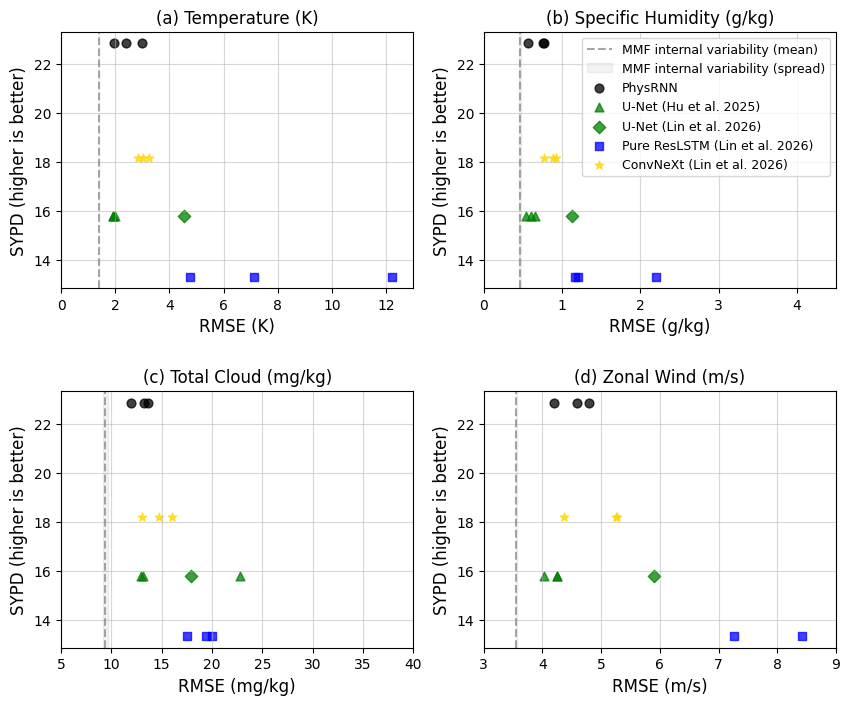

In [11]:
run_length = 12 # in months 

eval_cpu = True 
eval_cpu = False

SYPD_CPU =  {
    "U_net":  6.31,
    "U_net_lin":  6.31,
    "Pure ResLSTM": 5.67,
    "ConvNeXt":  2.322,
    "physRNN": 17.14
}
SYPD_GPU =  {
    "U_net":  15.789 ,
    "U_net_lin":  15.789 ,
    "Pure ResLSTM": 13.33,
    "ConvNeXt":  18.18,
    "physRNN": 22.857
}

model_styles = {
    'U_net':       {'color': 'green',   'marker': '^', 'label': 'U-Net (Hu et al. 2025)'},
    'U_net_lin':       {'color': 'green',   'marker': 'D', 'label': 'U-Net (Lin et al. 2026)'},
    'Pure ResLSTM': {'color': 'blue', 'marker': 's', 'label': 'Pure ResLSTM (Lin et al. 2026)'},
    'ConvNeXt': {'color': 'gold', 'marker': '*', 'label': 'ConvNeXt (Lin et al. 2026)'},
    'physRNN':     {'color': 'black', 'marker': 'o', 'label': 'PhysRNN'},
}

#model_styles = {
#    'U_net_lin':       {'color': 'green',   'marker': 'D', 'label': 'U-Net (Hu et al. 2025, Lin et al. 2026)'},
#    'Pure ResLSTM': {'color': 'blue', 'marker': 's', 'label': 'Pure ResLSTM (Lin et al. 2026)'},
#    'ConvNeXt': {'color': 'gold', 'marker': '*', 'label': 'ConvNeXt (Lin et al. 2026)'},
#    'physRNN':     {'color': 'black', 'marker': 'o', 'label': 'PhysRNN'},
#}

     #   'conf_loss': '*',
     #   'diff_loss': '^',
     #   'multirep': 'v',
     #   'v6': 'D'

if len(model_styles)==5:
 order = [0, 1, 6, 2, 3, 4,5]
else:
 order = [0, 1, 5, 2, 3, 4]

ylim_upper = {
    #'T': 5
    'T': 13, 
    #'Q': 0.7, 
    'Q': 4.5, 
    'CLDTOT': 40, 
    'CLDLIQ': 40,
    'CLDICE': 8, 
     'U': 9, 
    'V': 4.0
}
ylim_lower = {
    'T': 0.0, #0, 
    'Q': 0.0, 
    'CLDTOT': 5,  
    'CLDLIQ': 0, 'CLDICE': 0,  
    'U': 3, 
    'V': 0
}

online_var_settings = {
    'T':      {'var_title': 'Temperature',       'unit': 'K'},
    'Q':      {'var_title': 'Specific Humidity',  'unit': 'g/kg'},
    'U':      {'var_title': 'Zonal Wind',         'unit': 'm/s'},
    'V':      {'var_title': 'Meridional Wind',    'unit': 'm/s'},
    'CLDLIQ': {'var_title': 'Liquid Cloud',       'unit': 'mg/kg'},
    'CLDICE': {'var_title': 'Ice Cloud',          'unit': 'mg/kg'},
    'CLDTOT': {'var_title': 'Total Cloud',          'unit': 'mg/kg'}

}


#variables = ['T', 'Q', 'CLDLIQ', 'CLDICE']  # only vars present in rmse_dict
variables = ['T', 'Q', 'CLDTOT', 'U']  # only vars present in rmse_dict

sublabels = [f'({chr(97 + i)})' for i in range(len(variables))]

ref_casenames = ['mmf_a', 'mmf_b', 'mmf_c']


#fig = plt.figure(figsize=(10, 8), constrained_layout=True)
#gs  = gridspec.GridSpec(2, 2, figure=fig)
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4)
scatter_axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]

for ax, var, sublabel in zip(scatter_axes, variables, sublabels):

    # Reference line: mean over the 3 REF runs' nanmean RMSE
    ref_rmse_means = [
        np.nanmean(rmse_dict[('REF', cas, var)]) for cas in ref_casenames
    ]
    ref_mean = np.mean(ref_rmse_means)
    ax.axvline(
        x=ref_mean,
        linestyle='--', color='grey', alpha=0.7,
        label='MMF internal variability (mean)'
    )
    # Optionally shade the spread across the 3 REF runs
    ax.axvspan(
        min(ref_rmse_means), max(ref_rmse_means),
        alpha=0.10, color='grey', label='MMF internal variability (spread)'
    )

    for model_family, cfg in model_styles.items():
        # Collect all runs belonging to this model family
        keys = [(mf, cas, v) for (mf, cas, v) in rmse_dict if mf == model_family and v == var]
        if eval_cpu:
            sypd_val  = SYPD_CPU[model_family]
        else:
            sypd_val =  SYPD_GPU[model_family]
        #rmse_vals = [np.nanmean(rmse_dict[k]) for k in keys]
        complete_rmse   = [np.nanmean(rmse_dict[k]) for k in keys if len(rmse_dict[k]) == run_length]
        incomplete_rmse = [np.nanmean(rmse_dict[k]) for k in keys if len(rmse_dict[k]) < run_length]
    
        if complete_rmse:
            ax.scatter(
                complete_rmse,
                [sypd_val] * len(complete_rmse),
                marker=cfg['marker'],
                color=cfg['color'],
                alpha=0.75, s=40,
                label=cfg['label'],
                antialiased=True
            )
        if incomplete_rmse:
            ax.scatter(
                incomplete_rmse,
                [sypd_val] * len(incomplete_rmse),
                marker='x',              # special marker for crashed runs
                color=cfg['color'],
                alpha=0.75, s=60,        # slightly larger so the X is visible
                linewidths=1.5,
                label=f'{cfg["label"]} (incomplete)',
                antialiased=True
            )

    ax.set_xlim(left=ylim_lower[var], right=ylim_upper[var])
    ax.set_xlabel(f"RMSE ({online_var_settings[var]['unit']})", size=12)
    ax.set_ylabel("SYPD (higher is better)", size=12)
    ax.set_title(
        f"{sublabel} {online_var_settings[var]['var_title']} ({online_var_settings[var]['unit']})",
        loc='center'
    )
    ax.grid(True, alpha=0.5)

# Deduplicated shared legend on first axis
#handles, labels = scatter_axes[0].get_legend_handles_labels()
#by_label = dict(zip(labels, handles))
#scatter_axes[1].legend(by_label.values(), by_label.keys(), loc='upper right', frameon=True, fontsize=9)

handles, labels = scatter_axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ordered_handles = [list(by_label.values())[i] for i in order]
ordered_labels  = [list(by_label.keys())[i] for i in order]

scatter_axes[1].legend(ordered_handles, ordered_labels, loc='upper right', frameon=True, fontsize=9)


#plt.savefig("rmse_vs_sypd.png", dpi=150, bbox_inches='tight')
plt.show()

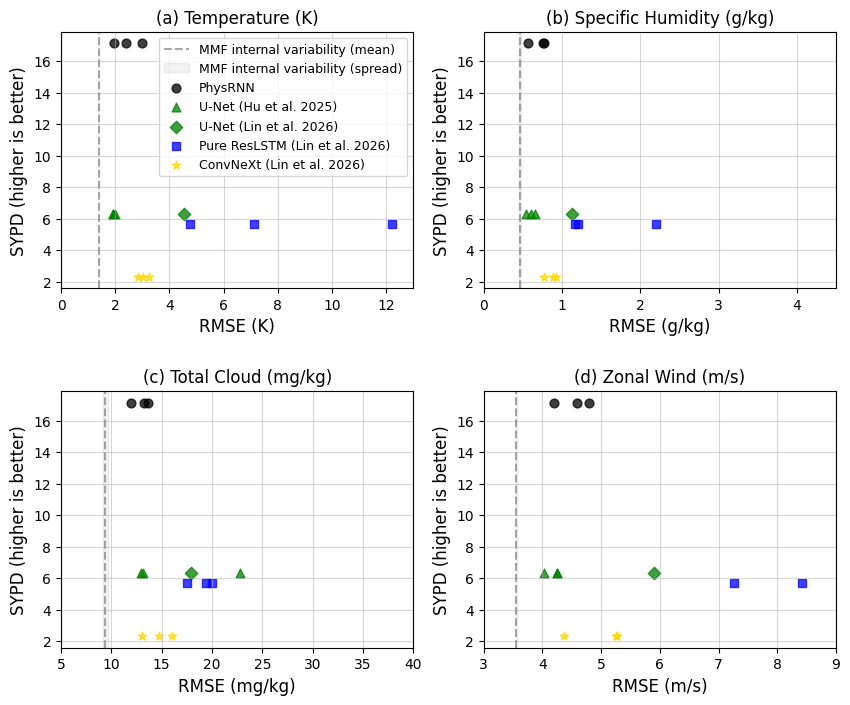

In [12]:
eval_cpu = True 

#fig = plt.figure(figsize=(10, 8), constrained_layout=True)
#gs  = gridspec.GridSpec(2, 2, figure=fig)
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4)
scatter_axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]

for ax, var, sublabel in zip(scatter_axes, variables, sublabels):

    # Reference line: mean over the 3 REF runs' nanmean RMSE
    ref_rmse_means = [
        np.nanmean(rmse_dict[('REF', cas, var)]) for cas in ref_casenames
    ]
    ref_mean = np.mean(ref_rmse_means)
    ax.axvline(
        x=ref_mean,
        linestyle='--', color='grey', alpha=0.7,
        label='MMF internal variability (mean)'
    )
    # Optionally shade the spread across the 3 REF runs
    ax.axvspan(
        min(ref_rmse_means), max(ref_rmse_means),
        alpha=0.10, color='grey', label='MMF internal variability (spread)'
    )

    for model_family, cfg in model_styles.items():
        # Collect all runs belonging to this model family
        keys = [(mf, cas, v) for (mf, cas, v) in rmse_dict if mf == model_family and v == var]
        if eval_cpu:
            sypd_val  = SYPD_CPU[model_family]
        else:
            sypd_val =  SYPD_GPU[model_family]
        #rmse_vals = [np.nanmean(rmse_dict[k]) for k in keys]
        complete_rmse   = [np.nanmean(rmse_dict[k]) for k in keys if len(rmse_dict[k]) == run_length]
        incomplete_rmse = [np.nanmean(rmse_dict[k]) for k in keys if len(rmse_dict[k]) < run_length]
    
        if complete_rmse:
            ax.scatter(
                complete_rmse,
                [sypd_val] * len(complete_rmse),
                marker=cfg['marker'],
                color=cfg['color'],
                alpha=0.75, s=40,
                label=cfg['label'],
                antialiased=True
            )
        if incomplete_rmse:
            ax.scatter(
                incomplete_rmse,
                [sypd_val] * len(incomplete_rmse),
                marker='x',              # special marker for crashed runs
                color=cfg['color'],
                alpha=0.75, s=60,        # slightly larger so the X is visible
                linewidths=1.5,
                label=f'{cfg["label"]} (incomplete)',
                antialiased=True
            )

    ax.set_xlim(left=ylim_lower[var], right=ylim_upper[var])
    ax.set_xlabel(f"RMSE ({online_var_settings[var]['unit']})", size=12)
    ax.set_ylabel("SYPD (higher is better)", size=12)
    ax.set_title(
        f"{sublabel} {online_var_settings[var]['var_title']} ({online_var_settings[var]['unit']})",
        loc='center'
    )
    ax.grid(True, alpha=0.5)

handles, labels = scatter_axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ordered_handles = [list(by_label.values())[i] for i in order]
ordered_labels  = [list(by_label.keys())[i] for i in order]

scatter_axes[0].legend(ordered_handles, ordered_labels, loc='upper right', frameon=True, fontsize=9)

#plt.savefig("rmse_vs_sypd.png", dpi=150, bbox_inches='tight')
plt.show()

rmse_dict

['U-Net', 'Pure ResLSTM', 'ConvNeXt', 'physRNN']


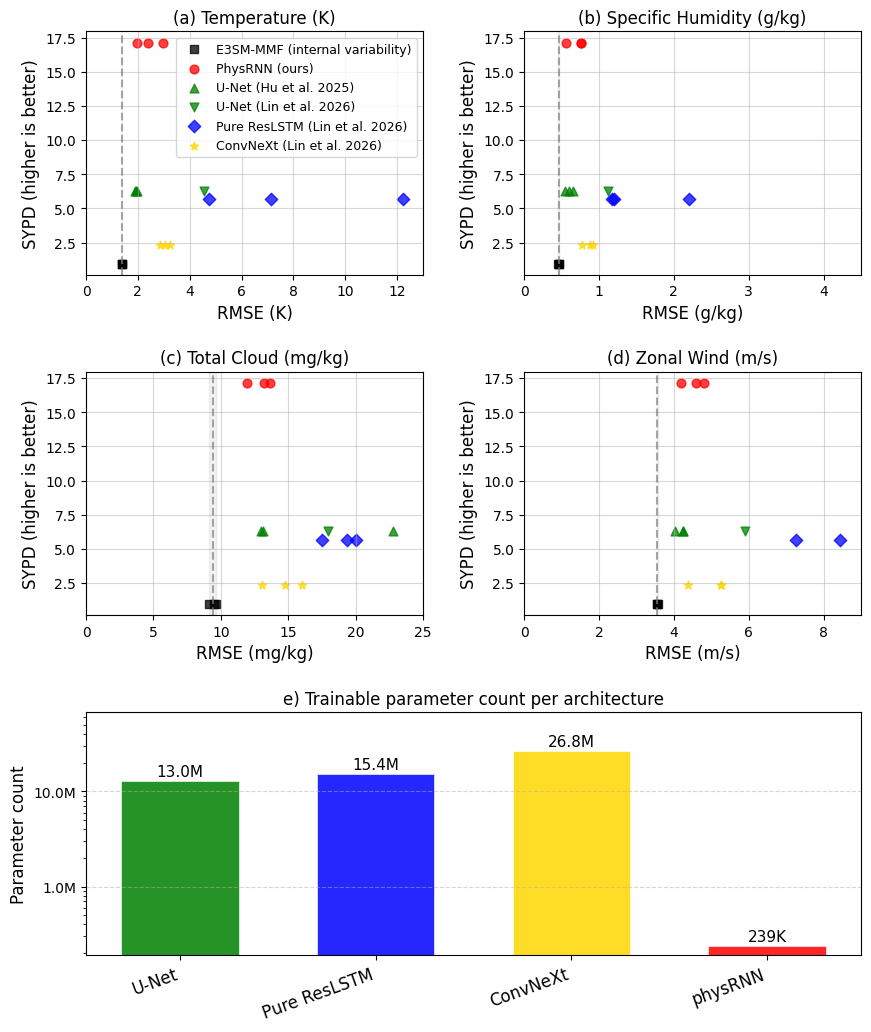

In [16]:
legend_outside=False 

SYPD_CPU_full =  {
    "REF": 0.963,
    "U_net":  6.31,
    "U_net_lin":  6.31,
    "Pure ResLSTM": 5.669,
    "ConvNeXt":  2.322,
    "physRNN": 17.14
}

ylim_upper = {
    #'T': 5
    'T': 13, 
    #'Q': 0.7, 
    'Q': 4.5, 
    'CLDTOT': 25, #40, 
    'CLDLIQ': 40,
    'CLDICE': 8, 
     'U': 9, 
    'V': 4.0
}
ylim_lower = {
    'T': 0.0, #0, 
    'Q': 0.0, 
    'CLDTOT': 0, #5,  
    'CLDLIQ': 0, 'CLDICE': 0,  
    'U': 0, 
    'V': 0
}
model_styles = {
    'REF':          {'color': 'black',   'marker': 's', 'label': 'E3SM-MMF (internal variability)'},
    'U_net':        {'color': 'green',   'marker': '^', 'label': 'U-Net (Hu et al. 2025)'},
    'U_net_lin':    {'color': 'green',   'marker': 'v', 'label': 'U-Net (Lin et al. 2026)'},
    'Pure ResLSTM': {'color': 'blue', 'marker': 'D',    'label': 'Pure ResLSTM (Lin et al. 2026)'},
    'ConvNeXt':     {'color': 'gold', 'marker': '*',    'label': 'ConvNeXt (Lin et al. 2026)'},
    'physRNN':      {'color': 'red', 'marker': 'o',      'label': 'PhysRNN (ours)'},
}

param_count = {
    "U-Net":        12975373,
    "Pure ResLSTM": 15395341,
    "ConvNeXt":   26805429,
    "physRNN":   238832,
}
colors_param = {
    'U-Net': 'green', 
    'Squeezeformer': 'purple', 
    'Pure ResLSTM': 'blue',
    'ConvNeXt': 'gold', 
    'Encoder-Decoder LSTM': 'orange',
    'physRNN': 'red',
}

model_styles = {
    'REF':          {'color': 'black', 'marker': 's', 'label': 'E3SM-MMF (internal variability)'},
    'U_net':        {'color': 'green', 'marker': '^', 'label': 'U-Net (Hu et al. 2025)'},
    'U_net_lin':    {'color': 'green', 'marker': 'v', 'label': 'U-Net (Lin et al. 2026)'},
    'Pure ResLSTM': {'color': 'blue',  'marker': 'D', 'label': 'Pure ResLSTM (Lin et al. 2026)'},
    'ConvNeXt':     {'color': 'gold',  'marker': '*', 'label': 'ConvNeXt (Lin et al. 2026)'},
    'physRNN':      {'color': 'red',   'marker': 'o', 'label': 'PhysRNN (ours)'},
}
order = [0, 5, 1, 2, 3, 4]

fig = plt.figure(figsize=(10, 12))

if legend_outside:
    gs = gridspec.GridSpec(4, 2, figure=fig, height_ratios=[1, 0.15, 1, 1], hspace=0.6, wspace=0.3)
    scatter_axes = [fig.add_subplot(gs[0, c]) for c in range(2)]  # row 1
    # row 1 (index 1) is the spacer — no axes added
    scatter_axes += [fig.add_subplot(gs[2, c]) for c in range(2)] # row 2
    ax_param = fig.add_subplot(gs[3, :])                          # row 3

else:
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)
    scatter_axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]
    ax_param = fig.add_subplot(gs[2, :])  # full-width bottom row

# ── rows 1 & 2: RMSE vs SYPD ────────────────────────────────────────────────
for ax, var, sublabel in zip(scatter_axes, variables, sublabels):
    ref_rmse_means = [np.nanmean(rmse_dict[('REF', cas, var)]) for cas in ref_casenames]
    ref_mean = np.mean(ref_rmse_means)
    ax.axvline(x=ref_mean, linestyle='--', color='grey', alpha=0.7)
    ax.axvspan(min(ref_rmse_means), max(ref_rmse_means), alpha=0.10, color='grey')

    for model_family, cfg in model_styles.items():
        keys = [(mf, cas, v) for (mf, cas, v) in rmse_dict if mf == model_family and v == var]
        sypd_val = SYPD_CPU_full[model_family] if eval_cpu else SYPD_GPU_full[model_family]
        complete_rmse   = [np.nanmean(rmse_dict[k]) for k in keys if len(rmse_dict[k]) == run_length]
        incomplete_rmse = [np.nanmean(rmse_dict[k]) for k in keys if len(rmse_dict[k]) < run_length]

        if complete_rmse:
            ax.scatter(complete_rmse, [sypd_val] * len(complete_rmse),
                       marker=cfg['marker'], color=cfg['color'],
                       alpha=0.75, s=40, label=cfg['label'], antialiased=True)
        if incomplete_rmse:
            ax.scatter(incomplete_rmse, [sypd_val] * len(incomplete_rmse),
                       marker='x', color=cfg['color'],
                       alpha=0.75, s=60, linewidths=1.5,
                       label=f'{cfg["label"]} (incomplete)', antialiased=True)

    ax.set_xlim(left=ylim_lower[var], right=ylim_upper[var])
    ax.set_xlabel(f"RMSE ({online_var_settings[var]['unit']})", size=12)
    ax.set_ylabel("SYPD (higher is better)", size=12)
    ax.set_title(f"{sublabel} {online_var_settings[var]['var_title']} ({online_var_settings[var]['unit']})",
                 loc='center')
    ax.grid(True, alpha=0.5)

handles, labels = scatter_axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ordered_handles = [list(by_label.values())[i] for i in order]
ordered_labels  = [list(by_label.keys())[i] for i in order]

if legend_outside:
 fig.legend(ordered_handles, ordered_labels,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.645),  # adjust vertical position between rows
           ncols=3,                       # spread entries across columns
           frameon=True, fontsize=11)
else:
 scatter_axes[0].legend(ordered_handles, ordered_labels, loc='upper right', frameon=True, fontsize=9)

    
# ── row 3: parameter count bar chart ────────────────────────────────────────
def format_param(v):
    if v >= 1e6:   return f'{v/1e6:.1f}M'
    elif v >= 1e3: return f'{v/1e3:.0f}K'
    return str(v)

names  = list(param_count.keys())
print(names)
counts = list(param_count.values())
x      = np.arange(len(names))
bars   = ax_param.bar(x, counts, width=0.6,
                      color=[colors_param[n] for n in names],
                      alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, counts):
    ax_param.text(bar.get_x() + bar.get_width() / 2, v * 1.03,
                  format_param(v), ha='center', va='bottom', fontsize=11)
ax_param.set_yscale('log')
ax_param.set_ylim(top=ax_param.get_ylim()[1] * 2)
ax_param.set_title(f"e) Trainable parameter count per architecture")
ax_param.set_ylabel('Parameter count', fontsize=12)
ax_param.set_xticks(x)
ax_param.set_xticklabels(names, rotation=20, ha='right', fontsize=12)
ax_param.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: format_param(v)))
ax_param.grid(axis='y', linestyle='--', alpha=0.5)

#plt.savefig("summary_figure.png", dpi=150, bbox_inches='tight')
plt.show()

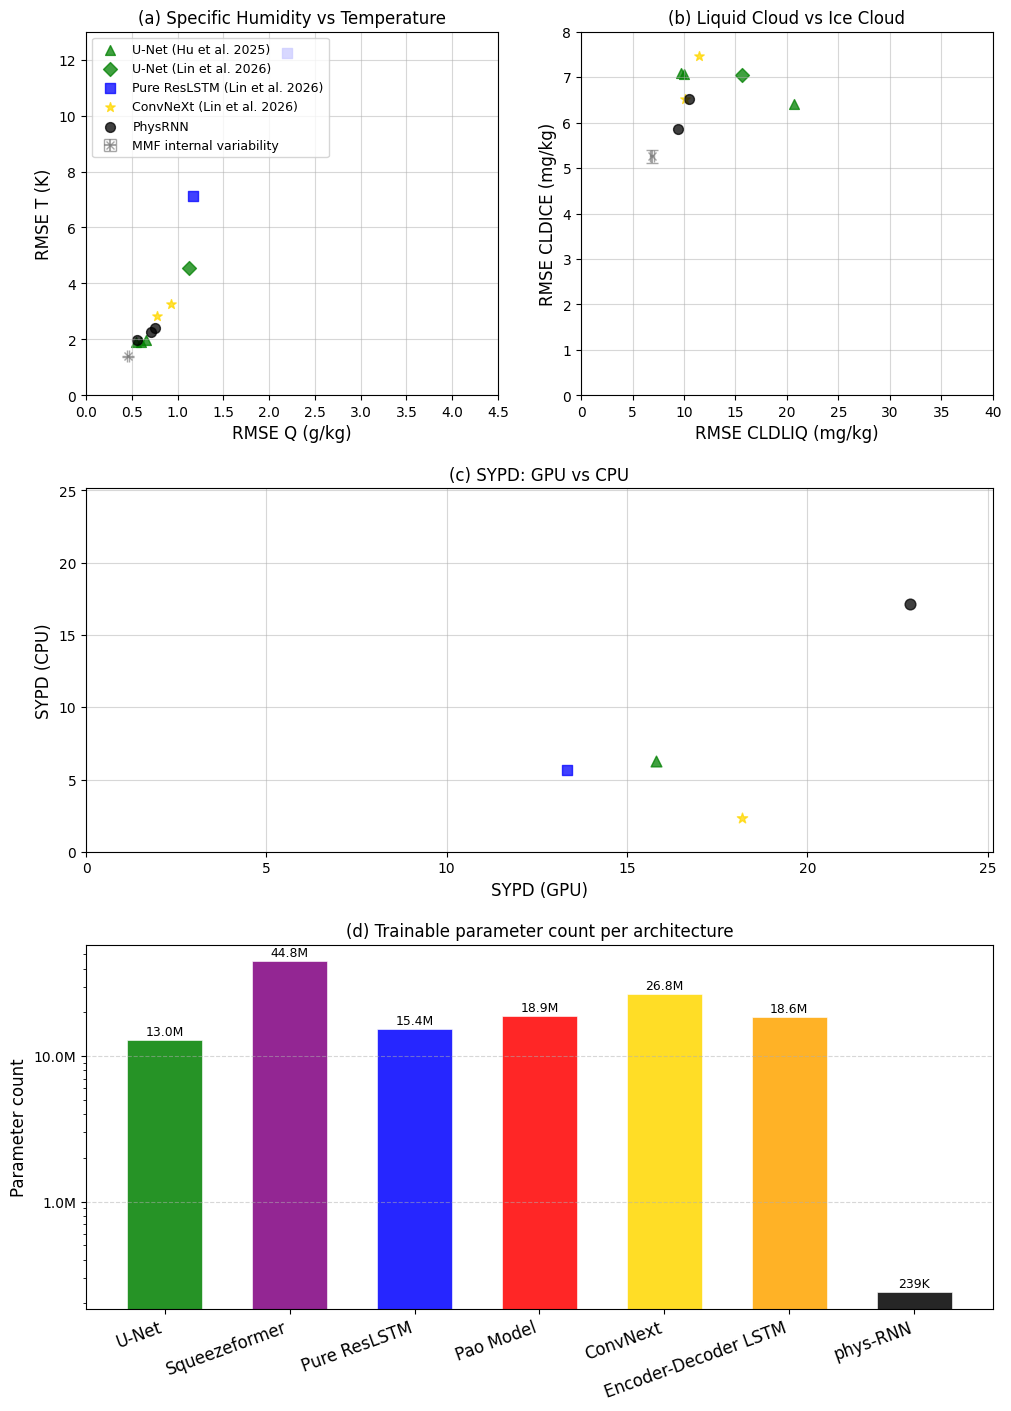

In [120]:
# ── configurable RMSE pairs for row 1 ──────────────────────────────────────
rmse_pairs = [
    ('U', 'T'),
    ('Q', 'CLDTOT'),  
]

rmse_pairs = [
    ('Q', 'T'),
    ('CLDLIQ', 'CLDICE'),  
]

if len(model_styles)==5:
 legend_order = [0, 1, 6, 2, 3, 4,5]
else:
 legend_order = [0, 1, 5, 2, 3, 4]

loc = "center right"
loc = "upper left"

model_styles2 = {
    'U_net':       {'color': 'green',   'marker': '^', 'label': 'U-Net (Hu et al. 2025)'},
    'Pure ResLSTM': {'color': 'blue', 'marker': 's', 'label': 'Pure ResLSTM (Lin et al. 2026)'},
    'ConvNeXt': {'color': 'gold', 'marker': '*', 'label': 'ConvNeXt (Lin et al. 2026)'},
    'physRNN':     {'color': 'black', 'marker': 'o', 'label': 'PhysRNN'},
}


# ── layout ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 14), constrained_layout=True)
hspace = 0.05
gs  = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1], hspace=hspace)

ax_rmse  = [fig.add_subplot(gs[0, c]) for c in range(2)]  # row 1: RMSE vs RMSE
ax_sypd  = fig.add_subplot(gs[1, :])                      # row 2: full-width SYPD
ax_param = fig.add_subplot(gs[2, :])                      # row 3: full-width param count

sublabels = [f'({chr(97 + i)})' for i in range(6)]

# ── row 1: RMSE vs RMSE ─────────────────────────────────────────────────────
for ax, (var_x, var_y), sublabel in zip(ax_rmse, rmse_pairs, sublabels[:2]):

    ref_x = [np.nanmean(rmse_dict[k]) for k in rmse_dict if k[0] == 'REF' and k[2] == var_x]
    ref_y = [np.nanmean(rmse_dict[k]) for k in rmse_dict if k[0] == 'REF' and k[2] == var_y]
    ax.errorbar(
        np.mean(ref_x), np.mean(ref_y),
        xerr=[[np.mean(ref_x) - min(ref_x)], [max(ref_x) - np.mean(ref_x)]],
        yerr=[[np.mean(ref_y) - min(ref_y)], [max(ref_y) - np.mean(ref_y)]],
        fmt='x', color='grey', alpha=0.7, capsize=4,
        label='MMF internal variability'
    )

    for model_family, cfg in model_styles.items():
        keys_x = [k for k in rmse_dict if k[0] == model_family and k[2] == var_x]
        casenames = [k[1] for k in keys_x]
        rmse_x = [np.nanmean(rmse_dict[(model_family, cas, var_x)]) for cas in casenames]
        rmse_y = [np.nanmean(rmse_dict[(model_family, cas, var_y)]) for cas in casenames]

        complete   = [(x, y) for x, y, k in zip(rmse_x, rmse_y, keys_x) if len(rmse_dict[k]) == 12]
        incomplete = [(x, y) for x, y, k in zip(rmse_x, rmse_y, keys_x) if len(rmse_dict[k]) < 12]

        if complete:
            ax.scatter(*zip(*complete), marker=cfg['marker'], color=cfg['color'],
                       alpha=0.75, s=50, label=cfg['label'], antialiased=True)
        if incomplete:
            ax.scatter(*zip(*incomplete), marker='x', color=cfg['color'],
                       alpha=0.75, s=60, linewidths=1.5,
                       label=f'{cfg["label"]} (incomplete)', antialiased=True)

    ax.set_xlabel(f"RMSE {var_x} ({online_var_settings[var_x]['unit']})", size=12)
    ax.set_ylabel(f"RMSE {var_y} ({online_var_settings[var_y]['unit']})", size=12)
    ax.set_xlim(left=ylim_lower[var_x], right=ylim_upper[var_x])
    ax.set_ylim(bottom=ylim_lower[var_y], top=ylim_upper[var_y])
    ax.set_title(f"{sublabel} {online_var_settings[var_x]['var_title']} vs "
                 f"{online_var_settings[var_y]['var_title']}", loc='center')
    ax.grid(True, alpha=0.5)

# shared legend for row 1 with custom ordering
handles, labels = ax_rmse[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ordered_handles = [list(by_label.values())[i] for i in legend_order if i < len(by_label)]
ordered_labels  = [list(by_label.keys())[i]   for i in legend_order if i < len(by_label)]
ax_rmse[0].legend(ordered_handles, ordered_labels, loc=loc, frameon=True, fontsize=9)

# ── row 2: SYPD CPU vs GPU (full width) ─────────────────────────────────────
for model_family, cfg in model_styles2.items():
    if model_family not in SYPD_CPU or model_family not in SYPD_GPU:
        continue
    ax_sypd.scatter(
        SYPD_GPU[model_family],
        SYPD_CPU[model_family],
        marker=cfg['marker'], color=cfg['color'],
        alpha=0.75, s=60,
        label=cfg['label'], antialiased=True
    )
   # ax_sypd.annotate(
   #     cfg['label'],
   #     (SYPD_CPU[model_family], SYPD_GPU[model_family]),
   #     textcoords='offset points', xytext=(6, 4), fontsize=9
   # )

lims = [0, max(max(SYPD_CPU.values()), max(SYPD_GPU.values())) * 1.10]
#ax_sypd.plot(lims, lims, '--', color='grey', alpha=0.5, label='CPU = GPU')
ax_sypd.set_xlim(lims); ax_sypd.set_ylim(lims)
ax_sypd.set_ylabel('SYPD (CPU)', size=12)
ax_sypd.set_xlabel('SYPD (GPU)', size=12)
ax_sypd.set_title(f"{sublabels[2]} SYPD: GPU vs CPU", loc='center')
ax_sypd.grid(True, alpha=0.5)
#ax_sypd.legend(loc=loc, frameon=True, fontsize=9)

# ── row 3: parameter count bar chart (full width) ───────────────────────────
param_count = {
    "U-Net":                12975373,
    "Squeezeformer":        44785225,
    "Pure ResLSTM":         15395341,
    "Pao Model":            18876133,
    "ConvNext":             26805429,
    "Encoder-Decoder LSTM": 18582976,
    "phys-RNN":               238832,
}
colors_param = {
    'U-Net': 'green', 'Squeezeformer': 'purple', 'Pure ResLSTM': 'blue',
    'Pao Model': 'red', 'ConvNext': 'gold', 'Encoder-Decoder LSTM': 'orange',
    'phys-RNN': 'black',
}
def format_param(v):
    if v >= 1e6:   return f'{v/1e6:.1f}M'
    elif v >= 1e3: return f'{v/1e3:.0f}K'
    return str(v)

names  = list(param_count.keys())
counts = list(param_count.values())
x      = np.arange(len(names))
bars   = ax_param.bar(x, counts, width=0.6,
                      color=[colors_param[n] for n in names],
                      alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, v in zip(bars, counts):
    ax_param.text(bar.get_x() + bar.get_width() / 2, v * 1.03,
                  format_param(v), ha='center', va='bottom', fontsize=8.9)
ax_param.set_yscale('log')
ax_param.set_title(f"{sublabels[3]} Trainable parameter count per architecture")
ax_param.set_ylabel('Parameter count', fontsize=12)
ax_param.set_xticks(x)
ax_param.set_xticklabels(names, rotation=20, ha='right', fontsize=12)
ax_param.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: format_param(v)))
ax_param.grid(axis='y', linestyle='--', alpha=0.5)

#plt.savefig("summary_figure.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
SYPD_lin = np.array((17.97901035, 17.97901035, 18.05589744,
                     18.90966668,19.03178614,18.65975565,
                     17.80983045,18.08638973,17.93128756,
                     21.78946853,21.9847479,22.20038272,
                     25.36398855,25.19805864,25.19227595,
                     23.54557187,23.82794497,23.447502])
                    
SYPD_lin_str = ["U-Net", "Squeezeformer", "pure_resLSTM", "Pao Model", "convnext", "encdec_LSTM"]

In [ ]:
huetal_sota_dict = {
    'T': (.99, 1.21),
    'Q': (.33, .25),
    'CLDLIQ': (13.05, 5.40),
    'CLDICE': (2.10, 2.29),
    'U': (1.70, 1.98),
    'V': (.79, .89)
}

mmf_ref_dict = {
    'T': .18,
    'Q': .06,
    'CLDLIQ': .80,
    'CLDICE': .65,
    'U': .44,
    'V': .35
}


def plot_global_rmse_vs_sypd(show = True, save_path = None):
    variables = ['T', 'Q', 'CLDLIQ', 'CLDICE', 'U', 'V']
    ylim_upper = {
        'T': 5,
        'Q': 0.7,
        'CLDLIQ': 40,
        'CLDICE': 8,
        'U': 9,
        'V': 2.5
    }
    marker_config_dict = {
        'standard': 'o',
        'conf_loss': '*',
        'diff_loss': '^',
        'multirep': 'v',
        'v6': 'D'
    }
    markersize_config_dict = {
        'standard': 8,
        'conf_loss': 11,
        'diff_loss': 8,
        'multirep': 8,
        'v6': 6
    }

    sublabels = [f'({chr(97 + i)})' for i in range(6)]
    # Create the figure with custom subplot layout
    fig = plt.figure(figsize=(11, 12.5), constrained_layout = True)
    gs = gridspec.GridSpec(4, 3, figure=fig, height_ratios=[1,1,.75,.75])

    #     # First row: 3 square scatter plots
    #     ax1 = plt.subplot2grid((4, 3), (0, 0))
    #     ax2 = plt.subplot2grid((4, 3), (0, 1))
    #     ax3 = plt.subplot2grid((4, 3), (0, 2))

    #     # Second row: 3 square scatter plots
    #     ax4 = plt.subplot2grid((4, 3), (1, 0))
    #     ax5 = plt.subplot2grid((4, 3), (1, 1))
    #     ax6 = plt.subplot2grid((4, 3), (1, 2))

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    # Second row: 3 square scatter plots
    ax4 = fig.add_subplot(gs[1, 0])
    ax5 = fig.add_subplot(gs[1, 1])
    ax6 = fig.add_subplot(gs[1, 2])

    scatter_axes = [ax1, ax2, ax3, ax4, ax5, ax6]

    #     # Third row: one rectangular plot spanning all 3 columns
    #     ax7 = plt.subplot2grid((4, 3), (2, 0), colspan=3)

    #     # Fourth row: one rectangular plot spanning all 3 columns
    #     ax8 = plt.subplot2grid((4, 3), (3, 0), colspan=3)

    # Third row: one rectangular plot spanning all 3 columns
    ax7 = fig.add_subplot(gs[2, :])

    # Fourth row: one rectangular plot spanning all 3 columns
    ax8 = fig.add_subplot(gs[3, :])
    
    sublabel_idx = 0
    for ax, var in zip(scatter_axes, variables):
        ax.axvline(x = min(huetal_sota_dict[var]), ymin = 0, ymax = 30, linestyle = '--', color = 'grey', alpha = .7)

        for idx, nn_sim in enumerate(nonnan_rmse_dict[var]):
            ax.scatter(nn_sim['rmse'], nn_sim['sypd'], marker = marker_config_dict[nn_sim['config_name']], color = color_dict[nn_sim['model_name']], alpha = .7, antialiased = True)

        ax.set_xlim(left = 0, right = ylim_upper[var])
        ax.tick_params(axis='both')
        ax.set_title(f"{sublabels[sublabel_idx]} {online_var_settings[var]['var_title']} ({online_var_settings[var]['unit']})", loc='center')  # Add main title with subplot label
        ax.set_xlabel(f"RMSE ({online_var_settings[var]['unit']})")  # Keep unit in x-label
        ax.grid(True, alpha = .5)
        sublabel_idx += 1

    # Create bar chart data for the middle plot
    unet_pc = [[pc_dict[config_name][model_name] for model_name in pc_dict[config_name].keys() if 'unet' in model_name][0] for config_name in config_names.keys()]
    squeezeformer_pc = [[pc_dict[config_name][model_name] for model_name in pc_dict[config_name].keys() if 'squeezeformer' in model_name][0] for config_name in config_names.keys()]
    pure_resLSTM_pc = [[pc_dict[config_name][model_name] for model_name in pc_dict[config_name].keys() if 'pure_resLSTM' in model_name][0] for config_name in config_names.keys()]
    pao_model_pc = [[pc_dict[config_name][model_name] for model_name in pc_dict[config_name].keys() if 'pao_model' in model_name][0] for config_name in config_names.keys()]
    convnext_pc = [[pc_dict[config_name][model_name] for model_name in pc_dict[config_name].keys() if 'convnext' in model_name][0] for config_name in config_names.keys()]
    encdec_lstm_pc = [[pc_dict[config_name][model_name] for model_name in pc_dict[config_name].keys() if 'encdec_lstm' in model_name][0] for config_name in config_names.keys()]

    x_positions = np.arange(len(config_names.values()))
    bar_width = 0.12
    
    # Calculate positions for 6 bars centered around each quarter
    offsets = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]

    # Plot grouped bar charts with 6 products
    ax7.bar(x_positions + offsets[0] * bar_width, unet_pc, bar_width, 
            label=model_names['unet'], color=color_dict['unet'])
    ax7.bar(x_positions + offsets[1] * bar_width, squeezeformer_pc, bar_width, 
            label=model_names['squeezeformer'], color=color_dict['squeezeformer'])
    ax7.bar(x_positions + offsets[2] * bar_width, pure_resLSTM_pc, bar_width, 
            label=model_names['pure_resLSTM'], color=color_dict['pure_resLSTM'])
    ax7.bar(x_positions + offsets[3] * bar_width, pao_model_pc, bar_width, 
            label=model_names['pao_model'], color=color_dict['pao_model'])
    ax7.bar(x_positions + offsets[4] * bar_width, convnext_pc, bar_width, 
            label=model_names['convnext'], color=color_dict['convnext'])
    ax7.bar(x_positions + offsets[5] * bar_width, encdec_lstm_pc, bar_width, 
            label=model_names['encdec_lstm'], color=color_dict['encdec_lstm'])

    # Customize the middle plot
    ax7.set_title('(g) Trainable Parameter Count Per Architecture Across Configurations')
    ax7.set_ylabel('Parameter Count')
    ax7.set_xticks(x_positions)
    ax7.set_xticklabels(config_names.values())
    # ax7.grid(axis='y', linestyle='--', alpha=0.5)

    # Create bar chart data for the bottom plot
    unet_tt = [np.mean([tt_dict[config_name][model_name] for model_name in tt_dict[config_name].keys() if 'unet' in model_name]) for config_name in config_names.keys()]
    squeezeformer_tt = [np.mean([tt_dict[config_name][model_name] for model_name in tt_dict[config_name].keys() if 'squeezeformer' in model_name]) for config_name in config_names.keys()]
    pure_resLSTM_tt = [np.mean([tt_dict[config_name][model_name] for model_name in tt_dict[config_name].keys() if 'pure_resLSTM' in model_name]) for config_name in config_names.keys()]
    pao_model_tt = [np.mean([tt_dict[config_name][model_name] for model_name in tt_dict[config_name].keys() if 'pao_model' in model_name]) for config_name in config_names.keys()]
    convnext_tt = [np.mean([tt_dict[config_name][model_name] for model_name in tt_dict[config_name].keys() if 'convnext' in model_name]) for config_name in config_names.keys()]
    encdec_lstm_tt = [np.mean([tt_dict[config_name][model_name] for model_name in tt_dict[config_name].keys() if 'encdec_lstm' in model_name]) for config_name in config_names.keys()]

    # Plot grouped bar charts with 6 products
    ax8.bar(x_positions + offsets[0] * bar_width, unet_tt, bar_width, 
            label=model_names['unet'], color=color_dict['unet'])
    ax8.bar(x_positions + offsets[1] * bar_width, squeezeformer_tt, bar_width, 
            label=model_names['squeezeformer'], color=color_dict['squeezeformer'])
    ax8.bar(x_positions + offsets[2] * bar_width, pure_resLSTM_tt, bar_width, 
            label=model_names['pure_resLSTM'], color=color_dict['pure_resLSTM'])
    ax8.bar(x_positions + offsets[3] * bar_width, pao_model_tt, bar_width, 
            label=model_names['pao_model'], color=color_dict['pao_model'])
    ax8.bar(x_positions + offsets[4] * bar_width, convnext_tt, bar_width, 
            label=model_names['convnext'], color=color_dict['convnext'])
    ax8.bar(x_positions + offsets[5] * bar_width, encdec_lstm_tt, bar_width, 
            label=model_names['encdec_lstm'], color=color_dict['encdec_lstm'])

    # Customize the middle plot
    ax8.set_title('(h) Seed-Averaged Training Time Per Architecture Across Configurations')
    ax8.set_ylabel('Hours')
    ax8.set_xticks(x_positions)
    ax8.set_xticklabels(config_names.values())
    # ax8.grid(axis='y', linestyle='--', alpha=0.5)

    for ax in [ax7, ax8]:
        ax.grid(True, axis = 'y', which='major', linestyle='-', alpha=0.7)
        ax.grid(True, axis = 'y', which='minor', linestyle='--', alpha=0.4)
        ax.minorticks_on()  # Enable minor ticks for more grid lines

    # --- Proxy lines for models (color key) ---
    huetal_line = mlines.Line2D([], [], color='grey', lw=2, linestyle = '--', label='Hu et al. 2025')
    unet_line = mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor=color_dict['unet'], markersize=8, label=f'{model_names["unet"]}')
    squeezeformer_line = mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor=color_dict['squeezeformer'], markersize=8, label=f'{model_names["squeezeformer"]}')
    pure_resLSTM_line = mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor=color_dict['pure_resLSTM'], markersize=8, label=f'{model_names["pure_resLSTM"]}')
    pao_model_line = mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor=color_dict['pao_model'], markersize=8, label=f'{model_names["pao_model"]}')
    convnext_line = mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor=color_dict['convnext'], markersize=8, label=f'{model_names["convnext"]}')
    encdec_lstm_line = mlines.Line2D([0], [0], marker='s', color='w', markerfacecolor=color_dict['encdec_lstm'], markersize=8, label=f'{model_names["encdec_lstm"]}')

    # --- Proxy "letters" for configurations (letter key) ---
    shape_handles = [
        mlines.Line2D([0], [0], marker=marker, color='w', markerfacecolor='gray', markersize=markersize_config_dict[label], label=config_names[label], linestyle='None') for label, marker in marker_config_dict.items()
    ]

    # First, add the model legend
    legend1 = fig.legend(handles=[huetal_line, unet_line, squeezeformer_line, pure_resLSTM_line, pao_model_line, convnext_line, encdec_lstm_line], 
                        loc='center left', bbox_to_anchor=(1.0, .6), 
                        title='Model Architectures')

    # Then, add the configuration legend
    legend2 = fig.legend(handles=shape_handles, 
                        loc='center left', bbox_to_anchor=(1.0, 0.35), 
                        title='Configurations')

    fig.gca().add_artist(legend1)  # Make sure both legends show up

    # handles = [line_mmf, line_unet, line_squeezeformer, line_pure_resLSTM, line_pao_model, line_convnext, line_encdec_lstm]
    # labels = ['MMF2', model_names['unet'], model_names['squeezeformer'], model_names['pure_resLSTM'], model_names['pao_model'], model_names['convnext'], model_names['encdec_lstm']]

    # fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.27, 0.5), title='Model')
    fig.suptitle(f'(a-f) Five Year Online Global Mean RMSE vs. SYPD')
    # Set a shared y-label for the first column
    scatter_axes[0].set_ylabel('SYPD')
    scatter_axes[3].set_ylabel('SYPD')
    plt.tight_layout()
    # plt.savefig('state_rmse_profiles_and_scalar.pdf', format='pdf', dpi=400, bbox_inches='tight')
    if save_path:
        plt.savefig(os.path.join(save_path, f'online_{num_years}_year_global_RMSE_model_comparison_{config_name}.png'), dpi=300, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close()

